CLIMATE STABILITY ANALYSIS- BRAGANCA VS VISEU

Group 11-   
20250873 - Aakarshak Asiwal (leader)  
20250013 - Mozhdeh Marvi  
20251273 - Fakhar Mahmood Khan  
20251224 - Fatima Zahra  
20251218 - Baohair Hameed  
20241794 - Rodrigo Souta  

**Check conclusion and the values of the last table**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Section 1- LOADING THE DATA and INITIAL DATA CLEANING

We load the data and clean the initial redundancies- we have a column 'time' which is more or less identical to the column 'date'.

We further convert the 'date' column into date-time format useful for extracting year, month and day information.

For 'sunshine_duration', we convert the data, given in seconds, into hours.

We further derive the length of day from the sunset and sunrise times, after which we drop sunset and sunrise columns entirely.

In [2]:
br = pd.read_csv('raw_BRAGANCA.csv')
vi = pd.read_csv('raw_VISEU.csv')

#removing redundant column 'time'
br, vi = br.drop(columns=['time']), vi.drop(columns=['time'])

#convert date into date-time form
br['date'], vi['date'] = pd.to_datetime(br['date']), pd.to_datetime(vi['date'])

#get year and month for grouping
br['year'],  vi['year']  = br['date'].dt.year,  vi['date'].dt.year
br['month'], vi['month'] = br['date'].dt.month, vi['date'].dt.month

#sunshine_duration from seconds to hours
br['sunshine_duration_hrs'] = br['sunshine_duration'] / 3600
vi['sunshine_duration_hrs'] = vi['sunshine_duration'] / 3600

#deriving day length and dropping sunset and sunrise times
br['sunrise_dt'], vi['sunrise_dt'] = pd.to_datetime(br['sunrise']), pd.to_datetime(vi['sunrise'])
br['sunset_dt'],  vi['sunset_dt']  = pd.to_datetime(br['sunset']),  pd.to_datetime(vi['sunset'])
br['day_length_hrs'] = (br['sunset_dt'] - br['sunrise_dt']).dt.total_seconds() / 3600
vi['day_length_hrs'] = (vi['sunset_dt'] - vi['sunrise_dt']).dt.total_seconds() / 3600
br = br.drop(columns=['sunrise', 'sunset', 'sunrise_dt', 'sunset_dt'])
vi = vi.drop(columns=['sunrise', 'sunset', 'sunrise_dt', 'sunset_dt'])

print("Data loaded successfully.")
print(f"Bragança — Date range: {br['date'].min().date()} to {br['date'].max().date()} | Rows: {len(br)}")
print(f"Viseu    — Date range: {vi['date'].min().date()} to {vi['date'].max().date()} | Rows: {len(vi)}")

Data loaded successfully.
Bragança — Date range: 2018-01-01 to 2026-02-28 | Rows: 2981
Viseu    — Date range: 2018-01-01 to 2026-02-28 | Rows: 2981


Section 2- SEASONAL CATEGORIZATION and DATA CLEANING

We categorize data from each year into seasons. In such an approach, we get four clean categories of similar temperature ranges to group by.

Why we don't utilize yearly or monthly statistics?-

Dividing by year is not very telling for the analysis- temperatures and atmospheric conditions in the winter are in stark contrast than in the summer.

Dividing by month would give us too many categories to work with- 12 labels to take care of everywhere instead of just 4.

Moreover, we also exclude the data from year 2026, as it only includes data up till February for the year, which would complicate analysis down the road for the other months, and also introduces a bias inside the Winter season

In [3]:
#assigning seasons
def assign_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

br['season'] = pd.Categorical(br['month'].map(assign_season), categories=season_order, ordered=True)
vi['season'] = pd.Categorical(vi['month'].map(assign_season), categories=season_order, ordered=True)

#removing data from 2026
br_clean = br[br['year'] != 2026].copy()
vi_clean = vi[vi['year'] != 2026].copy()

print(f"\nAfter excluding 2026:")
print(f"Bragança — {len(br_clean)} days | Viseu — {len(vi_clean)} days")


After excluding 2026:
Bragança — 2922 days | Viseu — 2922 days


Section 3- DIURNAL TEMPERATURE RANGE (DTR)

We compute the DTR to utilize the daily range of temperatures in our analysis- how much does temperature swing on a daily basis

In [4]:
br_clean['DTR'] = br_clean['temperature_2m_max'] - br_clean['temperature_2m_min']
vi_clean['DTR'] = vi_clean['temperature_2m_max'] - vi_clean['temperature_2m_min']

Section 4- SUMMARY STATISTICS

We compute the Mean, SD, CoV, and the Median, Maximum, Minimum and the IQR of all the feaatures of the data, divided by season

In [5]:

all_features = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'precipitation_sum', 'wind_speed_10m_max', 'wind_gusts_10m_max',
    'shortwave_radiation_sum', 'sunshine_duration_hrs',
    'relative_humidity_2m_mean', 'cloudcover_mean',
    'day_length_hrs', 'DTR'
]

mean_stats   = ['Mean', 'SD', 'CoV']
median_stats = ['Median', 'Min', 'Max', 'IQR']

def build_seasonal_summary(df, label):
    #making subcolumns- season, then statistic, then actual data
    mean_cols   = pd.MultiIndex.from_product([season_order, mean_stats],   names=['Season', 'Stat'])
    median_cols = pd.MultiIndex.from_product([season_order, median_stats], names=['Season', 'Stat'])

    mean_table   = pd.DataFrame(index=all_features, columns=mean_cols)
    median_table = pd.DataFrame(index=all_features, columns=median_cols)

    for feature in all_features:
        seasonal = df.groupby('season')[feature].agg(
            Mean   = 'mean',
            Median = 'median',
            SD     = 'std',
            CoV    = lambda x: (x.std() / x.mean()) * 100,
            Min    = 'min',
            Max    = 'max',
            IQR    = lambda x: x.quantile(0.75) - x.quantile(0.25)
        ).round(2)

        for season in season_order:
            for stat in mean_stats:
                mean_table.loc[feature, (season, stat)] = seasonal.loc[season, stat]
            for stat in median_stats:
                median_table.loc[feature, (season, stat)] = seasonal.loc[season, stat]

    print(f" {label}")
    print(f"{'-'*40}")
    print(f"\n--- TABLE 1: MEAN-BASED STATISTICS ---")
    display(mean_table)
    print(f"\n--- TABLE 2: MEDIAN-BASED STATISTICS ---")
    display(median_table)

    return mean_table, median_table

br_mean_table, br_median_table = build_seasonal_summary(br_clean, "BRAGANÇA — SEASONAL SUMMARY STATISTICS")
vi_mean_table, vi_median_table = build_seasonal_summary(vi_clean, "VISEU — SEASONAL SUMMARY STATISTICS")

 BRAGANÇA — SEASONAL SUMMARY STATISTICS
----------------------------------------

--- TABLE 1: MEAN-BASED STATISTICS ---


C:\Users\HP\AppData\Local\Temp\ipykernel_14400\3041265243.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal = df.groupby('season')[feature].agg(
C:\Users\HP\AppData\Local\Temp\ipykernel_14400\3041265243.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal = df.groupby('season')[feature].agg(
C:\Users\HP\AppData\Local\Temp\ipykernel_14400\3041265243.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
 

Season                    Winter                Spring                Summer  \
Stat                        Mean     SD     CoV   Mean     SD     CoV   Mean   
temperature_2m_max         10.34   2.94   28.41  16.66   5.18   31.08  27.64   
temperature_2m_min          2.52   3.37  133.74   6.16   3.62   58.77  14.69   
temperature_2m_mean         6.07   2.89   47.64  11.28   4.19   37.13  21.14   
precipitation_sum           2.59   5.91  228.33   2.49   4.58  183.82   0.85   
wind_speed_10m_max         16.25   7.42   45.63  18.05   6.14    34.0  16.75   
wind_gusts_10m_max         35.59   16.5   46.35  39.96  12.87   32.22  37.03   
shortwave_radiation_sum     7.43   3.82   51.39  18.72   6.83   36.48  25.66   
sunshine_duration_hrs       6.05   3.32   54.85   10.0   3.48    34.8  12.74   
relative_humidity_2m_mean  81.86  12.16   14.86  71.35  12.43   17.42  56.85   
cloudcover_mean            61.16  34.32   56.12   57.0  29.48   51.72  30.48   
day_length_hrs              9.76   0.64    6.57  13.29   1.13     8.5   14.6   
DTR                         7.82   3.09   39.46   10.5   3.46    33.0  12.95   

Season                                   Autumn                 
Stat                          SD     CoV   Mean     SD     CoV  
temperature_2m_max          4.82   17.44  18.58   5.94   31.97  
temperature_2m_min          3.41   23.25   9.25   4.04   43.64  
temperature_2m_mean         3.92   18.53  13.61    4.7   34.56  
precipitation_sum           3.17  373.86   2.99    6.2  207.74  
wind_speed_10m_max          3.85   22.98   17.3   6.66   38.47  
wind_gusts_10m_max           7.7   20.78  38.37  14.15   36.88  
shortwave_radiation_sum     4.16   16.21  12.05   5.89   48.89  
sunshine_duration_hrs       1.76   13.84   8.01    3.4   42.45  
relative_humidity_2m_mean  12.26   21.56  73.71  15.43   20.93  
cloudcover_mean            26.38   86.55  55.08  32.07   58.23  
day_length_hrs              0.63    4.33  11.12   1.13   10.16  
DTR                         2.74   21.14   9.33   3.62   38.83


--- TABLE 2: MEDIAN-BASED STATISTICS ---


Season                    Winter                     Spring                \
Stat                      Median   Min    Max    IQR Median    Min    Max   
temperature_2m_max          10.3   3.5   18.9   4.17   16.5    4.3   30.8   
temperature_2m_min          2.35  -5.6   11.4    5.0    6.1   -3.9   16.7   
temperature_2m_mean          6.2  -0.8   12.4    4.5   10.9    0.8   23.5   
precipitation_sum            0.0   0.0   60.0    2.0    0.1    0.0   25.6   
wind_speed_10m_max          15.1   3.5   44.3   10.7  17.55    6.4   49.9   
wind_gusts_10m_max          33.1   9.7  117.7   22.3   38.5   15.5  111.6   
shortwave_radiation_sum     7.56  0.66  16.67    5.6  19.04   2.39  30.89   
sunshine_duration_hrs       7.83   0.0   10.3   5.27  11.03    0.0  13.86   
relative_humidity_2m_mean   84.0    28     99   17.0   72.0     32     96   
cloudcover_mean             71.0     0    100  61.75   62.0      0    100   
day_length_hrs              9.47  9.13  11.23   1.03  13.38  11.23   15.0   
DTR                          8.1   1.1   17.8    4.8   10.7    2.4   19.5   

Season                           Summer                     Autumn        \
Stat                         IQR Median    Min    Max   IQR Median   Min   
temperature_2m_max           7.7   28.2   14.0   38.6  6.73   18.2   5.5   
temperature_2m_min           4.9   14.8    3.9   24.5  4.63    9.6  -1.3   
temperature_2m_mean         5.55   21.5    9.7   30.7   5.5  13.75   2.5   
precipitation_sum           2.92    0.0    0.0   38.7   0.1    0.0   0.0   
wind_speed_10m_max          8.22   16.6    6.8   31.5   5.5   16.4   3.9   
wind_gusts_10m_max          15.8   37.1   18.0   69.1  10.4   36.7  12.6   
shortwave_radiation_sum    10.58  26.54   6.61  31.28  4.68   11.4  0.85   
sunshine_duration_hrs       4.09  13.06   0.68  14.18  1.21   8.86   0.0   
relative_humidity_2m_mean   18.0   56.0     25     91  17.0   77.0    26   
cloudcover_mean             51.0   24.0      0     99  43.0   57.0     0   
day_length_hrs              2.02  14.88  13.15  15.22   1.0  11.07  9.38   
DTR                          5.6   13.5    3.6   19.1   3.6    9.3   1.2   

Season                                  
Stat                         Max   IQR  
temperature_2m_max          32.6   9.6  
temperature_2m_min          19.4   6.1  
temperature_2m_mean         25.7  7.12  
precipitation_sum           44.2   2.6  
wind_speed_10m_max          43.2   9.1  
wind_gusts_10m_max          92.5  18.7  
shortwave_radiation_sum    23.71  9.59  
sunshine_duration_hrs      12.24  4.03  
relative_humidity_2m_mean     98  25.0  
cloudcover_mean              100  57.0  
day_length_hrs             13.15  2.01  
DTR                         18.9   5.9

 VISEU — SEASONAL SUMMARY STATISTICS
----------------------------------------

--- TABLE 1: MEAN-BASED STATISTICS ---


C:\Users\HP\AppData\Local\Temp\ipykernel_14400\3041265243.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal = df.groupby('season')[feature].agg(
C:\Users\HP\AppData\Local\Temp\ipykernel_14400\3041265243.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal = df.groupby('season')[feature].agg(
C:\Users\HP\AppData\Local\Temp\ipykernel_14400\3041265243.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
 

Season                    Winter                Spring                Summer  \
Stat                        Mean     SD     CoV   Mean     SD     CoV   Mean   
temperature_2m_max         12.69   2.79   22.01  18.06   5.15   28.54  28.26   
temperature_2m_min          4.94   3.27   66.11   8.23   3.42   41.52  15.39   
temperature_2m_mean         8.41    2.7   32.13  12.91   4.03   31.25  21.49   
precipitation_sum           3.87   8.56  220.85   3.43   6.43  187.17   0.85   
wind_speed_10m_max         17.17   6.35   37.01  18.82   5.56   29.57  17.52   
wind_gusts_10m_max         32.64  12.63   38.69  36.91  10.45   28.32  35.11   
shortwave_radiation_sum     7.88   3.84    48.7  18.57   6.95   37.43  25.36   
sunshine_duration_hrs       6.24   3.27   52.35    9.7   3.64   37.56  12.45   
relative_humidity_2m_mean  80.55  11.69   14.52   73.4  13.25   18.05  63.15   
cloudcover_mean            58.37   36.0   61.67  58.82   29.9   50.82   33.9   
day_length_hrs              9.85   0.61    6.23  13.25   1.08    8.19   14.5   
DTR                         7.75   2.87   37.08   9.83   3.36   34.22  12.87   

Season                                   Autumn                 
Stat                          SD     CoV   Mean     SD     CoV  
temperature_2m_max          5.16   18.26  20.16   5.79   28.72  
temperature_2m_min          3.28   21.33  11.17   3.98    35.6  
temperature_2m_mean         4.03   18.76   15.3   4.55   29.73  
precipitation_sum           3.13  367.58   4.33   9.11  210.25  
wind_speed_10m_max          3.71   21.18  17.45   6.32   36.18  
wind_gusts_10m_max          5.93   16.88  34.32  12.17   35.47  
shortwave_radiation_sum     4.24   16.72  12.13   5.91   48.72  
sunshine_duration_hrs       1.86   14.95   7.83   3.51   44.87  
relative_humidity_2m_mean  13.74   21.76  74.96  15.78   21.05  
cloudcover_mean            27.76   81.88  55.41  32.84   59.28  
day_length_hrs               0.6    4.17  11.16   1.09    9.72  
DTR                         3.21   24.91   8.99   3.56   39.58


--- TABLE 2: MEDIAN-BASED STATISTICS ---


Season                    Winter                    Spring                \
Stat                      Median   Min    Max   IQR Median    Min    Max   
temperature_2m_max         12.55   4.1   21.8   3.8   17.6    6.6   32.8   
temperature_2m_min           5.1  -2.8   12.6   4.8    8.2   -1.1   19.0   
temperature_2m_mean         8.65   1.2   15.5  4.07   12.6    4.0   25.0   
precipitation_sum            0.0   0.0   72.8  2.98    0.3    0.0   44.0   
wind_speed_10m_max          16.5   4.2   45.0  9.05   18.5    5.6   41.0   
wind_gusts_10m_max          31.3   9.7  111.2  17.0  35.45   16.2   87.1   
shortwave_radiation_sum      8.3  0.76  17.28  5.59  19.21   1.93   30.5   
sunshine_duration_hrs       7.91   0.0  10.35  4.95  10.95    0.0   13.6   
relative_humidity_2m_mean   83.0    36     99  18.0   76.0     30     96   
cloudcover_mean             66.5     0    100  68.0   64.0      0    100   
day_length_hrs              9.58  9.25  11.25  0.98  13.33  11.28  14.88   
DTR                          7.9   1.3   16.7   4.1    9.6    2.2   18.0   

Season                           Summer                     Autumn        \
Stat                         IQR Median    Min    Max   IQR Median   Min   
temperature_2m_max           7.4   28.6   14.9   40.2   7.9   19.5   8.2   
temperature_2m_min           4.7   15.1    6.7   25.9   4.3   11.7  -0.7   
temperature_2m_mean          5.6   21.3   11.1   33.3   5.7   15.4   4.3   
precipitation_sum            3.6    0.0    0.0   41.7   0.1    0.1   0.0   
wind_speed_10m_max           7.4   17.6    7.1   30.5  4.85   16.9   5.3   
wind_gusts_10m_max          12.9   34.9   16.9   60.5   7.6   32.8  11.9   
shortwave_radiation_sum    10.62  26.24   5.49  31.38   5.0  11.68  0.94   
sunshine_duration_hrs       4.43  12.96   0.03  14.06  1.25   8.84   0.0   
relative_humidity_2m_mean   19.0   66.0     25     93  20.0   78.5    16   
cloudcover_mean             48.0   31.0      0     99  48.0   61.0     0   
day_length_hrs              1.92  14.77  13.12   15.1  0.97  11.11   9.5   
DTR                          5.4   13.5    3.2   19.5   4.5    8.8   1.7   

Season                                  
Stat                         Max   IQR  
temperature_2m_max          35.0   8.9  
temperature_2m_min          23.1   5.5  
temperature_2m_mean         28.1   6.3  
precipitation_sum           74.8  4.22  
wind_speed_10m_max          41.3  9.33  
wind_gusts_10m_max          79.9  15.2  
shortwave_radiation_sum    23.97  9.61  
sunshine_duration_hrs      12.21  4.87  
relative_humidity_2m_mean     98  20.0  
cloudcover_mean              100  60.0  
day_length_hrs              13.1  1.92  
DTR                         19.5   5.5

Section 5- TEMPERATURE STABILITY INDEX

We calculate 3 major components:
- Standard Deviation of daily mean temperatures, grouped by seasons 
- Mean of Diurnal Temperature Range- Diurnal Temperature Range (DTR) is the difference between the maximum temperature of the day and the minimum, giving us a view of how much temperature varies on a daily basis. This is also grouped by season.
- Inter-Annual Coefficient of Variation- The inter-annual CoV presents us with a view of the variability of seasonal temperatures every year- we see which season has the least CoV (more stable temperatures) and which has the most.

Finally, we compute the Stability Index- the mean of all 3 (SD, DTR and CoV) which are first normalized on a 0-1 scale (as the measure scales were different).
Higher Stability Index means more stable temperature.

In [6]:
br.describe()

,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_gusts_10m_max,shortwave_radiation_sum,sunshine_duration,relative_humidity_2m_mean,cloudcover_mean,date,latitude,longitude,year,month,sunshine_duration_hrs,day_length_hrs
count,2981.000000,2981.000000,2981.000000,2981.000000,2981.000000,2981.000000,2981.000000,2981.000000,2981.000000,2981.000000,2981,2.981000e+03,2.981000e+03,2981.000000,2981.000000,2981.000000,2981.000000
mean,18.169909,8.072123,12.914156,2.303925,17.178229,37.923818,15.823341,32831.139302,71.180141,51.521637,2022-01-30 00:00:00.000000256,4.180600e+01,-6.757000e+00,2021.589400,6.423012,9.119761,12.166907
min,1.900000,-5.600000,-0.800000,0.000000,3.500000,9.700000,0.660000,0.000000,25.000000,0.000000,2018-01-01 00:00:00,4.180600e+01,-6.757000e+00,2018.000000,1.000000,0.000000,9.133333
25%,11.600000,3.600000,7.600000,0.000000,12.600000,28.800000,8.190000,26379.730000,59.000000,21.000000,2020-01-16 00:00:00,4.180600e+01,-6.757000e+00,2020.000000,3.000000,7.327703,10.150000
50%,16.900000,7.600000,11.900000,0.000000,16.600000,36.700000,15.340000,35373.060000,73.000000,53.000000,2022-01-30 00:00:00,4.180600e+01,-6.757000e+00,2022.000000,6.000000,9.825850,12.150000
75%,24.500000,12.500000,18.100000,1.700000,20.700000,45.000000,24.000000,45276.360000,85.000000,82.000000,2024-02-14 00:00:00,4.180600e+01,-6.757000e+00,2024.000000,9.000000,12.576767,14.200000
max,38.600000,24.500000,30.700000,60.000000,49.900000,117.700000,31.280000,51048.160000,99.000000,100.000000,2026-02-28 00:00:00,4.180600e+01,-6.757000e+00,2026.000000,12.000000,14.180044,15.216667
std,7.897875,5.747366,6.744538,5.262802,6.285216,13.471364,8.744148,14394.830828,16.012204,33.066274,NaN,2.231479e-12,3.553310e-14,2.353737,3.487349,3.998564,2.091068


In [7]:
vi.describe()

,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,wind_gusts_10m_max,shortwave_radiation_sum,sunshine_duration,relative_humidity_2m_mean,cloudcover_mean,date,latitude,longitude,year,month,sunshine_duration_hrs,day_length_hrs
count,2981.000000,2981.000000,2981.000000,2981.000000,2981.000000,2981.000000,2981.000000,2981.000000,2981.000000,2981.000000,2981,2.981000e+03,2.981000e+03,2981.000000,2981.000000,2981.000000,2981.000000
mean,19.662999,9.850654,14.424019,3.271285,17.776786,34.885475,15.832895,32285.977400,73.249245,52.180141,2022-01-30 00:00:00.000000256,4.066100e+01,-7.910000e+00,2021.589400,6.423012,8.968327,12.163497
min,4.100000,-2.800000,1.200000,0.000000,4.200000,9.700000,0.760000,0.000000,16.000000,0.000000,2018-01-01 00:00:00,4.066100e+01,-7.910000e+00,2018.000000,1.000000,0.000000,9.250000
25%,13.400000,5.900000,9.600000,0.000000,13.700000,27.700000,8.670000,25402.890000,64.000000,21.000000,2020-01-16 00:00:00,4.066100e+01,-7.910000e+00,2020.000000,3.000000,7.056358,10.216667
50%,18.200000,9.800000,13.500000,0.000000,17.600000,34.200000,15.310000,35130.140000,75.000000,56.000000,2022-01-30 00:00:00,4.066100e+01,-7.910000e+00,2022.000000,6.000000,9.758372,12.150000
75%,25.300000,13.800000,18.900000,2.400000,21.200000,40.300000,23.660000,44470.280000,85.000000,83.000000,2024-02-14 00:00:00,4.066100e+01,-7.910000e+00,2024.000000,9.000000,12.352856,14.116667
max,40.200000,25.900000,33.300000,74.800000,45.000000,111.200000,31.380000,50618.450000,99.000000,100.000000,2026-02-28 00:00:00,4.066100e+01,-7.910000e+00,2026.000000,12.000000,14.060681,15.100000
std,7.442676,5.207983,6.134516,7.572201,5.667051,10.907965,8.585708,14283.115822,15.124049,33.485348,NaN,3.290365e-12,1.296958e-13,2.353737,3.487349,3.967532,2.006466


In [8]:
def build_stability_index(df_br, df_vi):
    #component a: inter-season SD of daily mean temperature
    br_comp_a = df_br.groupby('season')['temperature_2m_mean'].std()
    vi_comp_a = df_vi.groupby('season')['temperature_2m_mean'].std()

    #component b: mean DTR per season
    br_comp_b = df_br.groupby('season')['DTR'].mean()
    vi_comp_b = df_vi.groupby('season')['DTR'].mean()

    #component c- onter-annual CoV per season
    br_yearly = df_br.groupby(['year', 'season'])['temperature_2m_mean'].mean()
    vi_yearly = df_vi.groupby(['year', 'season'])['temperature_2m_mean'].mean()
    br_comp_c = br_yearly.groupby('season').agg(lambda x: (x.std() / x.mean()) * 100)
    vi_comp_c = vi_yearly.groupby('season').agg(lambda x: (x.std() / x.mean()) * 100)

    #pooling data for normalizing for Stabilty Index
    norm_a = max(br_comp_a.max(), vi_comp_a.max())
    norm_b = max(br_comp_b.max(), vi_comp_b.max())
    norm_c = max(br_comp_c.max(), vi_comp_c.max())

    results = {}
    for label, comp_a, comp_b, comp_c in [
        ('BRAGANÇA', br_comp_a, br_comp_b, br_comp_c),
        ('VISEU',    vi_comp_a, vi_comp_b, vi_comp_c)
    ]:
        stab = pd.DataFrame({
            'Within_Season_SD (°C)' : comp_a.round(3),
            'Mean_DTR (°C)'         : comp_b.round(3),
            'Interannual_CoV (%)'   : comp_c.round(3),
            #computing stability index
            'Stability_Index (0-1)' : (1-(comp_a / norm_a + comp_b / norm_b + comp_c / norm_c) / 3).round(3)
        })

        print(f" {label} — TEMPERATURE STABILITY INDEX")
        print(f" (Raw components shown | Index normalized 0–1 | Higher = More Stable)")
        print(f"{'-'*70}")
        display(stab)

        results[label] = stab

    return results['BRAGANÇA'], results['VISEU']

br_stability, vi_stability = build_stability_index(br_clean, vi_clean)

 BRAGANÇA — TEMPERATURE STABILITY INDEX
 (Raw components shown | Index normalized 0–1 | Higher = More Stable)
----------------------------------------------------------------------


C:\Users\HP\AppData\Local\Temp\ipykernel_14400\2306791449.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  br_comp_a = df_br.groupby('season')['temperature_2m_mean'].std()
C:\Users\HP\AppData\Local\Temp\ipykernel_14400\2306791449.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vi_comp_a = df_vi.groupby('season')['temperature_2m_mean'].std()
C:\Users\HP\AppData\Local\Temp\ipykernel_14400\2306791449.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future 

,Within_Season_SD (°C),Mean_DTR (°C),Interannual_CoV (%),Stability_Index (0-1)
season,,,,
Winter,2.892,7.821,10.482,0.260
Spring,4.186,10.499,7.319,0.200
Summer,3.917,12.952,4.752,0.238
Autumn,4.703,9.335,4.188,0.293


 VISEU — TEMPERATURE STABILITY INDEX
 (Raw components shown | Index normalized 0–1 | Higher = More Stable)
----------------------------------------------------------------------


,Within_Season_SD (°C),Mean_DTR (°C),Interannual_CoV (%),Stability_Index (0-1)
season,,,,
Winter,2.702,7.750,7.388,0.374
Spring,4.033,9.826,6.922,0.241
Summer,4.032,12.871,5.240,0.216
Autumn,4.548,8.995,3.550,0.333


Setion 6- EFFECTS OF FEATURES ON TEMPERATURE TARGETS

We use Pearson Correlation method as the features to analyze are completely Quantitative data.
We run a correlation of all features against-
- Mean Temperature
- DTR (Diurnal Temperature Range)
- Temperature Stability Index

Furthermore, we also visualize this using a heatmap

 BRAGANÇA — CORRELATIONS
-------------------------

--- PEARSON CORRELATION: FEATURES vs TEMPERATURE TARGETS ---


,temperature_2m_mean,DTR
sunshine_duration_hrs,0.586,0.778
shortwave_radiation_sum,0.737,0.805
cloudcover_mean,-0.368,-0.706
relative_humidity_2m_mean,-0.680,-0.811
precipitation_sum,-0.165,-0.469
wind_speed_10m_max,-0.045,-0.357
wind_gusts_10m_max,-0.040,-0.365
day_length_hrs,0.732,0.554



--- PEARSON CORRELATION: FEATURES vs STABILITY INDEX ---


,Stability_Index
sunshine_duration_hrs,-0.309
shortwave_radiation_sum,-0.431
cloudcover_mean,0.049
relative_humidity_2m_mean,0.174
precipitation_sum,0.056
wind_speed_10m_max,-0.052
wind_gusts_10m_max,-0.054
day_length_hrs,-0.546


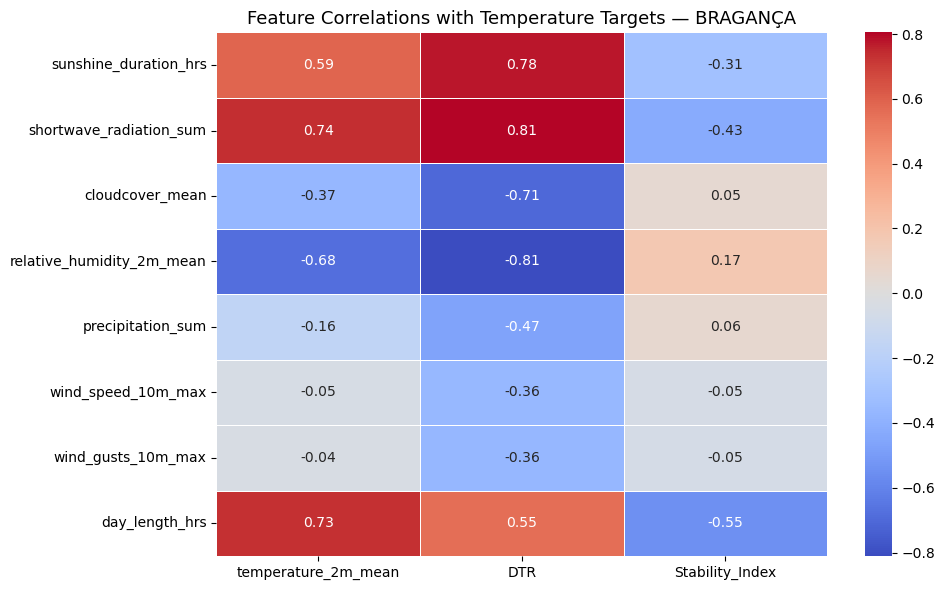

 VISEU — CORRELATIONS
-------------------------

--- PEARSON CORRELATION: FEATURES vs TEMPERATURE TARGETS ---


,temperature_2m_mean,DTR
sunshine_duration_hrs,0.563,0.764
shortwave_radiation_sum,0.716,0.790
cloudcover_mean,-0.327,-0.669
relative_humidity_2m_mean,-0.598,-0.744
precipitation_sum,-0.179,-0.503
wind_speed_10m_max,-0.047,-0.258
wind_gusts_10m_max,-0.000,-0.257
day_length_hrs,0.698,0.516



--- PEARSON CORRELATION: FEATURES vs STABILITY INDEX ---


,Stability_Index
sunshine_duration_hrs,-0.565
shortwave_radiation_sum,-0.754
cloudcover_mean,0.195
relative_humidity_2m_mean,0.366
precipitation_sum,0.142
wind_speed_10m_max,-0.067
wind_gusts_10m_max,-0.118
day_length_hrs,-0.892


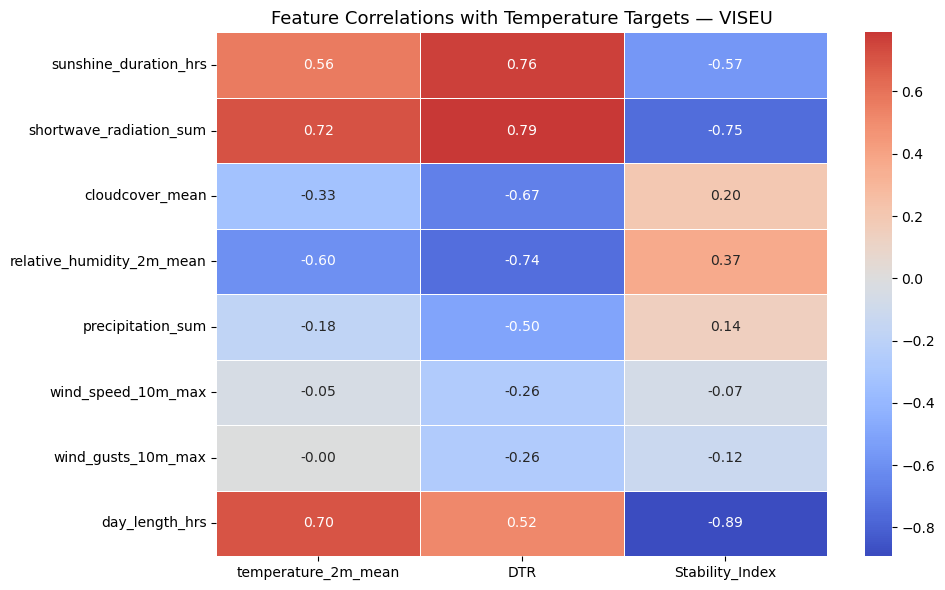

In [9]:
feature_cols = [
    'sunshine_duration_hrs', 'shortwave_radiation_sum',
    'cloudcover_mean', 'relative_humidity_2m_mean',
    'precipitation_sum', 'wind_speed_10m_max',
    'wind_gusts_10m_max', 'day_length_hrs'
]

def build_correlations(df, stability, label):
    corr_targets = ['temperature_2m_mean', 'DTR']
    corr_df = df[feature_cols + corr_targets].corr()[corr_targets].drop(corr_targets)

    #merging stability index (seasonal) back to the daily data
    df = df.copy()
    df['Stability_Index'] = df['season'].map(stability['Stability_Index (0-1)'].to_dict())
    corr_stability = df[feature_cols + ['Stability_Index']].corr()[['Stability_Index']].drop(['Stability_Index'])
    print(f" {label}")
    print(f"{'-'*25}")
    print("\n--- PEARSON CORRELATION: FEATURES vs TEMPERATURE TARGETS ---")
    display(corr_df.round(3))
    print("\n--- PEARSON CORRELATION: FEATURES vs STABILITY INDEX ---")
    display(corr_stability.round(3))

    #heatmap- features vs statistics
    fig, ax = plt.subplots(figsize=(10, 6))
    full_corr = pd.concat([corr_df, corr_stability], axis=1)
    sns.heatmap(full_corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, ax=ax)
    ax.set_title(f'Feature Correlations with Temperature Targets — {label.split("—")[0].strip()}', fontsize=13)
    plt.tight_layout()
    plt.show()

    return corr_df, corr_stability

br_corr, br_corr_stab = build_correlations(br_clean, br_stability, "BRAGANÇA — CORRELATIONS")
vi_corr, vi_corr_stab = build_correlations(vi_clean, vi_stability, "VISEU — CORRELATIONS")



Section 7- Anomalous Temperature days detection

We utilize boxplots and IQRs (Inter-Quartile Ranges- the difference between Q3 and Q1) to detect temperature outliers in both Braganca and Viseu on a SEASONAL basis- all data from all years is collected into 4 separate season bins and then analysed.
Utilizing IQRs, we set a maximum range of the dataset beyond which, any data points can be considered as "anomalous" or "extreme values", which is usually set to 1.5 times the Quartile for maximum coverage of normal data and being a symmetrical coefficient. 

 BRAGANÇA — EXTREME TEMPERATURE EVENTS
---------------------------------------

Extreme days detected: 7
Breakdown by season:
season
Winter    0
Spring    6
Summer    1
Autumn    0
Name: count, dtype: int64


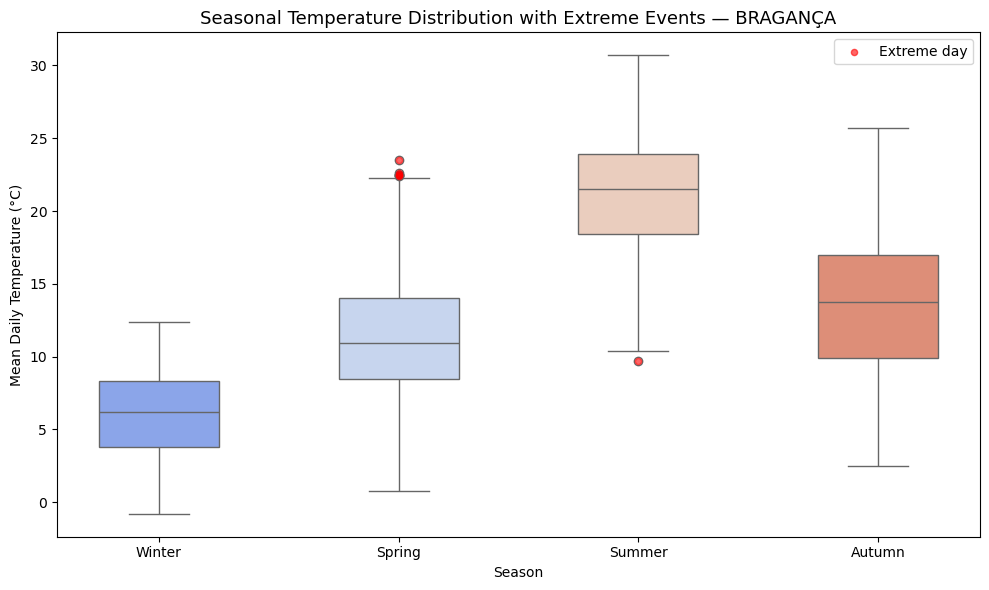


--- MEAN VARIABLE VALUES: EXTREME vs NORMAL DAYS ---


,Normal Days,Extreme Days
sunshine_duration_hrs,9.21,11.37
cloudcover_mean,50.87,50.14
relative_humidity_2m_mean,70.92,53.71
wind_speed_10m_max,17.10,15.03
precipitation_sum,2.23,1.76
shortwave_radiation_sum,16.00,24.24
DTR,10.16,13.61


 VISEU — EXTREME TEMPERATURE EVENTS
---------------------------------------

Extreme days detected: 6
Breakdown by season:
season
Winter    0
Spring    3
Summer    1
Autumn    2
Name: count, dtype: int64


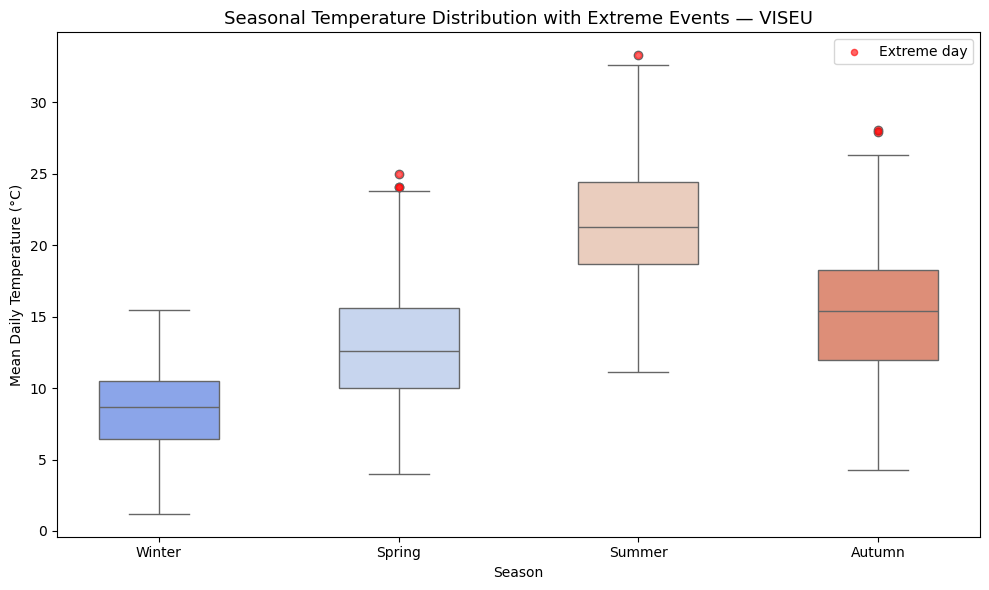


--- MEAN VARIABLE VALUES: EXTREME vs NORMAL DAYS ---


,Normal Days,Extreme Days
sunshine_duration_hrs,9.07,12.30
cloudcover_mean,51.59,47.50
relative_humidity_2m_mean,73.04,40.50
wind_speed_10m_max,17.74,17.90
precipitation_sum,3.12,0.00
shortwave_radiation_sum,16.01,25.73
DTR,9.86,14.42


In [10]:
def detect_extremes(df, label):
    extreme_days = []

    for season in season_order:
        season_data = df[df['season'] == season]['temperature_2m_mean']
        Q1  = season_data.quantile(0.25)
        Q3  = season_data.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        mask = (
            (df['season'] == season) &
            ((df['temperature_2m_mean'] < lower) |
             (df['temperature_2m_mean'] > upper))
        )
        extreme_days.append(df[mask])

    df_extreme = pd.concat(extreme_days).sort_values('date')
    print(f" {label}")
    print(f"{'-'*39}")
    print(f"\nExtreme days detected: {len(df_extreme)}")
    print(f"Breakdown by season:\n{df_extreme['season'].value_counts().reindex(season_order)}")

    #seasonal extreme boxplots
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=df, x='season', y='temperature_2m_mean', hue='season',
                order=season_order, palette='coolwarm', width=0.5, ax=ax, legend=False)
    ax.scatter(
        df_extreme['season'].cat.codes,
        df_extreme['temperature_2m_mean'],
        color='red', zorder=5, s=20, alpha=0.6, label='Extreme day'
    )
    ax.set_title(f'Seasonal Temperature Distribution with Extreme Events — {label.split("—")[0].strip()}', fontsize=13)
    ax.set_xlabel('Season')
    ax.set_ylabel('Mean Daily Temperature (°C)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    #extreme vs normal days- feature comparison
    profile_features = [
        'sunshine_duration_hrs', 'cloudcover_mean',
        'relative_humidity_2m_mean', 'wind_speed_10m_max',
        'precipitation_sum', 'shortwave_radiation_sum', 'DTR'
    ]

    df = df.copy()
    df['is_extreme'] = df['date'].isin(df_extreme['date'])
    extreme_profile = df.groupby('is_extreme')[profile_features].mean().round(2)
    extreme_profile.index = ['Normal Days', 'Extreme Days']

    print("\n--- MEAN VARIABLE VALUES: EXTREME vs NORMAL DAYS ---")
    display(extreme_profile.T)

    return df_extreme

br_extreme = detect_extremes(br_clean, "BRAGANÇA — EXTREME TEMPERATURE EVENTS")
vi_extreme = detect_extremes(vi_clean, "VISEU — EXTREME TEMPERATURE EVENTS")

Section 8- Thermal Envelope (monthly)

The thermal envelope is a way to visualize the temperature ranges of both Braganca and Viseu- how hot does each month get and by what range.

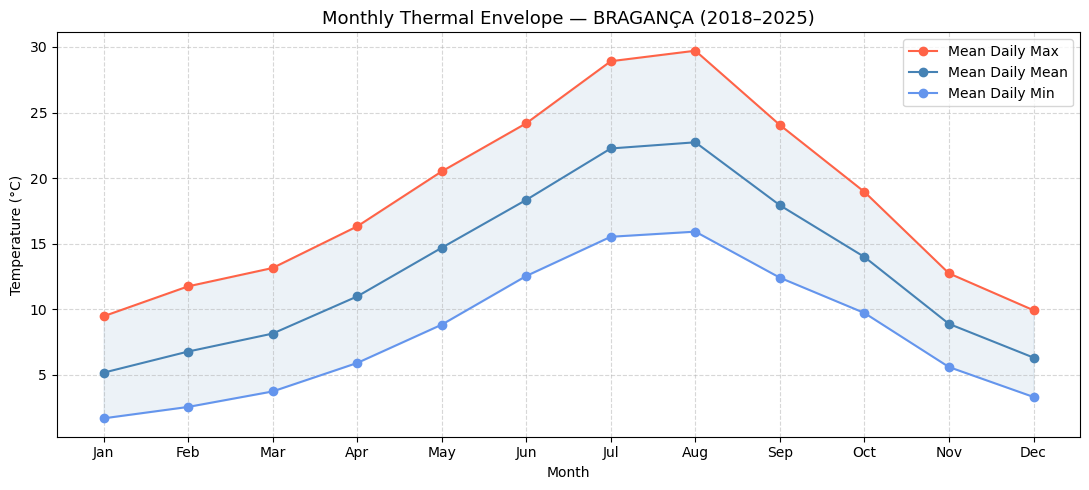

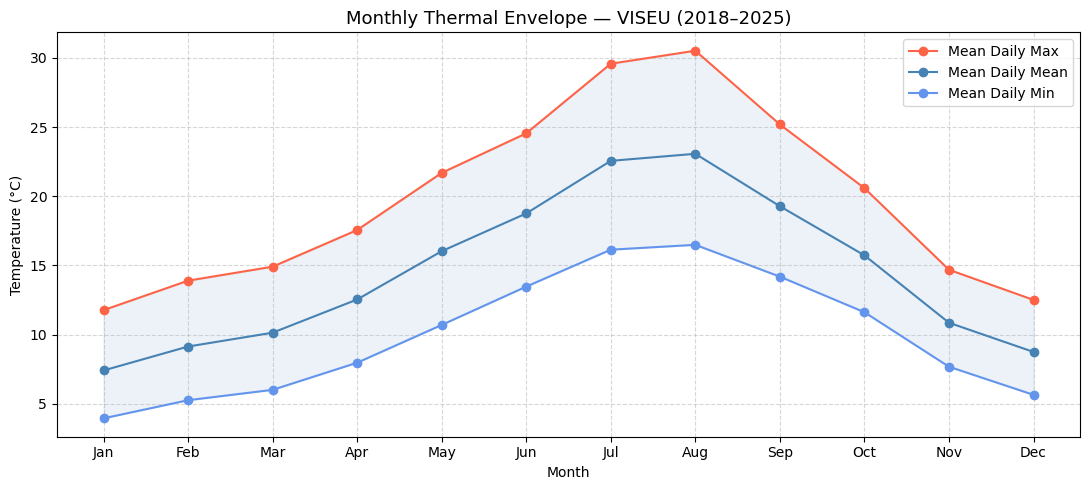

In [11]:
def plot_thermal_envelope(df, label):
    monthly = df.groupby('month').agg(
        Mean_Max  = ('temperature_2m_max',  'mean'),
        Mean_Min  = ('temperature_2m_min',  'mean'),
        Mean_Mean = ('temperature_2m_mean', 'mean')
    ).round(2)

    month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(month_labels, monthly['Mean_Max'],  marker='o', color='tomato',           label='Mean Daily Max')
    ax.plot(month_labels, monthly['Mean_Mean'], marker='o', color='steelblue',        label='Mean Daily Mean')
    ax.plot(month_labels, monthly['Mean_Min'],  marker='o', color='cornflowerblue',   label='Mean Daily Min')
    ax.fill_between(month_labels, monthly['Mean_Min'], monthly['Mean_Max'],
                    alpha=0.1, color='steelblue')
    ax.set_title(f'Monthly Thermal Envelope — {label.split("—")[0].strip()} (2018–2025)', fontsize=13)
    ax.set_xlabel('Month')
    ax.set_ylabel('Temperature (°C)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_thermal_envelope(br_clean, "BRAGANÇA — MONTHLY THERMAL ENVELOPE")
plot_thermal_envelope(vi_clean, "VISEU — MONTHLY THERMAL ENVELOPE")

Section 9- POSITIVE DEVIATION and HOT-DAY FREQUENCY

We consider positive deviations from the mean maximum temperatures on a monthly basis, as these events are stressor events for temperature control- such events drive higher energy consumption and thus, higher costs.

 BRAGANÇA — POSITIVE DEVIATIONS
--------------------------------

--- FREQUENCY OF HIGH-TEMPERATURE DAYS ---
  Days ≥ 25°C: 700 days (24.0% of dataset)
  Days ≥ 30°C: 283 days (9.7% of dataset)
  Days ≥ 35°C: 35 days (1.2% of dataset)


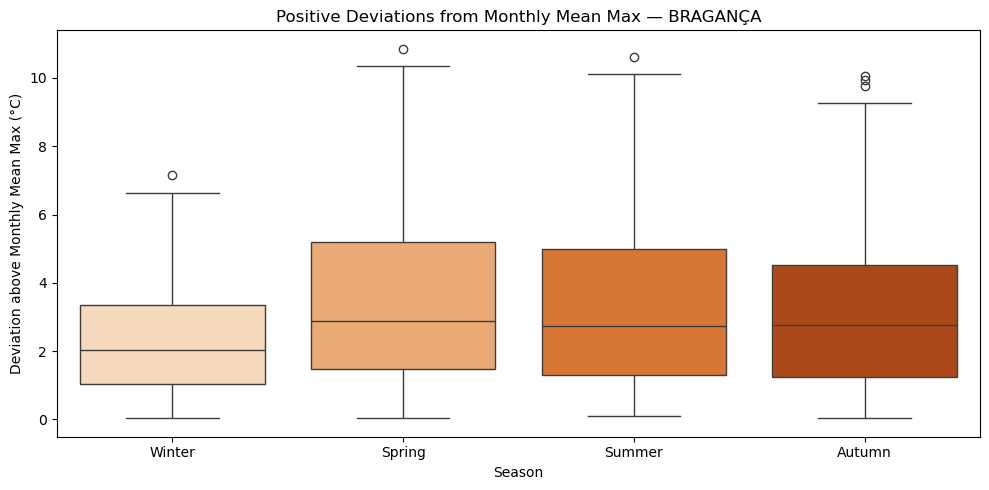

 VISEU — POSITIVE DEVIATIONS
--------------------------------

--- FREQUENCY OF HIGH-TEMPERATURE DAYS ---
  Days ≥ 25°C: 786 days (26.9% of dataset)
  Days ≥ 30°C: 352 days (12.0% of dataset)
  Days ≥ 35°C: 64 days (2.2% of dataset)


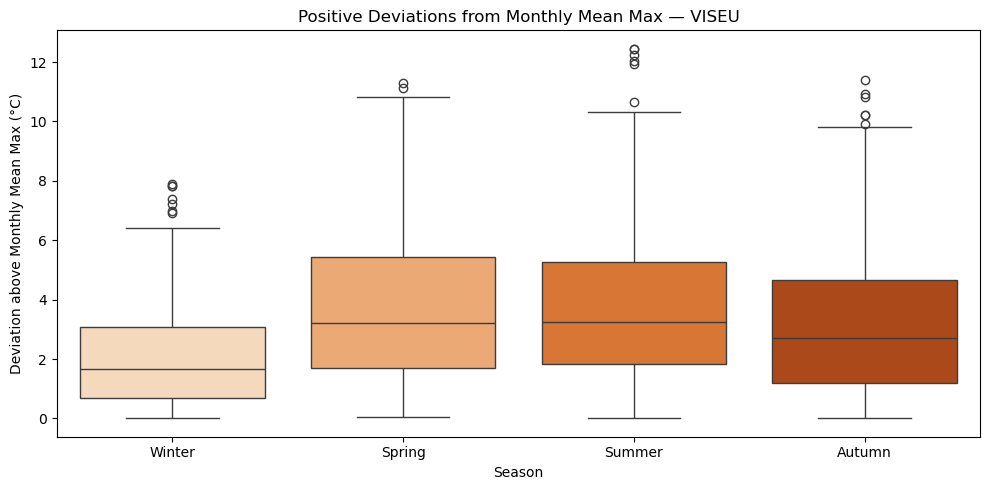

In [12]:
def analyse_deviations(df, label):
    monthly_max_mean = df.groupby('month')['temperature_2m_max'].transform('mean')
    df = df.copy()
    df['pos_deviation_max'] = (df['temperature_2m_max'] - monthly_max_mean).clip(lower=0)
    print(f" {label}")
    print(f"{'-'*32}")

    thresholds = [25, 30, 35]
    print("\n--- FREQUENCY OF HIGH-TEMPERATURE DAYS ---")
    for t in thresholds:
        count = (df['temperature_2m_max'] >= t).sum()
        pct   = count / len(df) * 100
        print(f"  Days ≥ {t}°C: {count} days ({pct:.1f}% of dataset)")

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=df[df['pos_deviation_max'] > 0],
                x='season', y='pos_deviation_max', hue='season',
                order=season_order, palette='Oranges', ax=ax, legend=False)
    ax.set_title(f'Positive Deviations from Monthly Mean Max — {label.split("—")[0].strip()}', fontsize=12)
    ax.set_xlabel('Season')
    ax.set_ylabel('Deviation above Monthly Mean Max (°C)')
    plt.tight_layout()
    plt.show()

analyse_deviations(br_clean, "BRAGANÇA — POSITIVE DEVIATIONS")
analyse_deviations(vi_clean, "VISEU — POSITIVE DEVIATIONS")

Section 10- SUMMARY AND CONCLUSIONS

In [13]:
conclusions = {
    'Metric'                        : [
        'Overall Winter Mean Temp (°C)',
        'Overall Summer Mean Temp (°C)',
        'Days ≥ 25°C',
        'Days ≥ 30°C',
        'Days ≥ 35°C',
        'Extreme Events (Tukey)',
        'Summer Stability Index (0-1)',
        'Autumn Stability Index (0-1)',
    ],
    'Bragança' : [6.07,  21.14, 700, 283, 35,  7, 0.238, 0.293],
    'Viseu'    : [8.41,  21.49, 786, 352, 64,  6, 0.381, 0.235],
    'Advantage': [
        'Bragança', 'Bragança', 'Bragança', 'Bragança', 'Bragança',
        'Viseu', 'Viseu', 'Bragança'
    ]
}

summary_df = pd.DataFrame(conclusions).set_index('Metric')
display(summary_df)

,Bragança,Viseu,Advantage
Metric,,,
Overall Winter Mean Temp (°C),6.070,8.410,Bragança
Overall Summer Mean Temp (°C),21.140,21.490,Bragança
Days ≥ 25°C,700.000,786.000,Bragança
Days ≥ 30°C,283.000,352.000,Bragança
Days ≥ 35°C,35.000,64.000,Bragança
Extreme Events (Tukey),7.000,6.000,Viseu
Summer Stability Index (0-1),0.238,0.381,Viseu
Autumn Stability Index (0-1),0.293,0.235,Bragança


CONCLUSION:
Bragança is the recommended location for the cold-storage logistics facility.

Key drivers:
  - Lower mean temperatures across all seasons
  - 83% fewer extreme heat days (≥35°C) than Viseu
  - 17% fewer days exceeding 25°C
  - Lower Autumn Stability Index (more predictable peak season)

Viseu's marginal advantages in Summer stability is outweighed by its consistently higher thermal load across the year.

**Complete!!!!!**